# 03 — Feature Engineering and SageMaker Feature Store

This notebook implements the Week module deliverable:

> Perform feature engineering on raw data and store it in a Feature Store. Split your feature data into training (~40%), test (~10%), validation (~10%) datasets. Reserve some data for "production data" (~40%).

Steps:

1. Pull the cleaned Parquet review data from Athena into a pandas DataFrame.
2. Build sentiment labels from star ratings and exclude 3-star neutral reviews.
3. Balance the two classes (≥10,000 records per class).
4. Engineer numeric and categorical features.
5. Assign a `split_type` of `train`, `validation`, `test`, or `production` to each record using a 40/10/10/40 split.
6. Create a SageMaker Feature Group and ingest the engineered records (offline store on S3).
7. Sanity-check the feature group with `describe()` and a sample Athena query against the offline store.

In [7]:
%pip install --disable-pip-version-check --quiet "sagemaker>=2.230.0,<3.0.0" awswrangler PyAthena scikit-learn
print("Install complete. IMPORTANT: restart the kernel now before running the next cell.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.3.0 which is incompatible.
autogluon-multimodal 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-learn 1.8.0 which is incompatible.
sagemaker-studio-analytics-extension 0.3.0 requires sparkmagic==0.22.0, but you have sparkmagic 0.21.0 which is incompatible.
snowflake-connector-python 3.17.4 requires cffi<2.0.0,>=1.9, but you have cffi 2.0.0 which is incompatible.
sparkmagic 0.21.0 requir

Note: you may need to restart the kernel to use updated packages.
Install complete. IMPORTANT: restart the kernel now before running the next cell.


In [1]:
import re
import time
from datetime import datetime, timezone
from pathlib import Path
from time import gmtime, strftime

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sagemaker
import seaborn as sns
from pyathena import connect
from sagemaker.feature_store.feature_definition import FeatureDefinition, FeatureTypeEnum
from sagemaker.feature_store.feature_group import FeatureGroup

from plot_style import apply_style, PURPLE_SENTIMENT, PURPLE_SPLITS

%store -r bucket
%store -r region
%store -r database_name
%store -r s3_staging_dir
%store -r parquet_table_name

apply_style()
report_dir = Path("../reports")
report_dir.mkdir(parents=True, exist_ok=True)

sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)
table = f"{database_name}.{parquet_table_name}"
print("Source table:", table)
print("Bucket:      ", bucket)
print("Role:        ", role)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Source table: yelp_db.reviews_parquet
Bucket:       yelp-sentiment-mlops-045456814877
Role:         arn:aws:iam::045456814877:role/LabRole


## 1. Pull a labeled, balanced sample

We pull enough rows to comfortably exceed the rubric requirement of ≥10,000 records per class even after the 40/10/10/40 split.

In [2]:
ROWS_PER_CLASS = 25000

positive_df = pd.read_sql(
    f"SELECT review_id, business_id, user_id, stars, review_text, date, review_char_length "
    f"FROM {table} WHERE stars >= 4 LIMIT {ROWS_PER_CLASS}",
    conn,
)
negative_df = pd.read_sql(
    f"SELECT review_id, business_id, user_id, stars, review_text, date, review_char_length "
    f"FROM {table} WHERE stars <= 2 LIMIT {ROWS_PER_CLASS}",
    conn,
)

print(f"Positive rows: {len(positive_df):,}")
print(f"Negative rows: {len(negative_df):,}")

raw_df = pd.concat([positive_df, negative_df], ignore_index=True)
raw_df = raw_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
raw_df.head()

/tmp/ipykernel_1541/918497364.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  positive_df = pd.read_sql(


/tmp/ipykernel_1541/918497364.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  negative_df = pd.read_sql(


Positive rows: 25,000
Negative rows: 25,000


,review_id,business_id,user_id,stars,review_text,date,review_char_length
0,EA_ijm26Wi-L-Whgz5KP3A,vwWPyZSLtggyIFzmhk4PLQ,alUlVVMx9NtfrvK4xAQy2w,2.0,I love Mexican food but this place was just ba...,2015-05-30 02:30:42,727
1,9UJFn-NzMAy6bR6DNw2h5g,N2i1U4Z6GHEw9V02N2u6JA,mYd8HNp6wXU9j0qv_Dr5IQ,4.0,"This is a nice little old school hotel, good f...",2016-11-07 18:49:08,545
2,TcGKXkausbkZYInpv_IMag,EjwrtCJDCZBUS_uTvpHMSw,raccLemMnCJCKjZBac6fEA,5.0,I've never had a bad experience at Skeeters. I...,2012-03-19 15:54:20,297
3,qOtwtkU0Z5AGipoqeNeNKA,gXg277YblY5xsaeMzJ73TA,sG9dTFp2WwWbRJVjj5gH2w,4.0,"Without doubt, one of the best Asian restauran...",2016-01-24 01:13:42,770
4,OgaZ10vP3Ium1C4VWy8gKQ,psI9u_iVuWFcchWheFAySA,xhL0WFrhWRWo6BK3XcVhhQ,1.0,Wow - this place has such potential. Obvious c...,2011-08-06 01:51:59,389


## 2. Feature engineering

- `sentiment_label` (int): 1 for positive, 0 for negative — used as the model target.
- `sentiment` (string): "positive" / "negative" for human-readable analysis.
- `clean_text` (string): lowercased, whitespace-normalized review text.
- `review_word_count` (int): number of word tokens in the cleaned text.
- `review_char_length` (int): already provided by Athena.
- `has_exclamation` / `has_question` (int): simple punctuation signals that correlate with sentiment.
- `review_year` (int): year extracted from the review date, useful for drift monitoring later.

In [3]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    return re.sub(r"\s+", " ", text)

def word_count(text: str) -> int:
    return len(re.findall(r"[a-z']+", text or ""))

features_df = raw_df.copy()
features_df["sentiment"] = np.where(features_df["stars"] >= 4, "positive", "negative")
features_df["sentiment_label"] = (features_df["sentiment"] == "positive").astype(int)
features_df["clean_text"] = features_df["review_text"].astype(str).map(clean_text)
features_df["review_word_count"] = features_df["clean_text"].map(word_count)
features_df["has_exclamation"] = features_df["clean_text"].str.contains("!", regex=False).astype(int)
features_df["has_question"] = features_df["clean_text"].str.contains("?", regex=False).astype(int)
features_df["review_year"] = pd.to_datetime(features_df["date"], errors="coerce").dt.year.fillna(0).astype(int)

features_df = features_df.dropna(subset=["review_id", "clean_text"])
features_df = features_df[features_df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Engineered feature counts by sentiment:")
print(features_df["sentiment"].value_counts())
features_df.head()

Engineered feature counts by sentiment:
sentiment
negative    25000
positive    25000
Name: count, dtype: int64


,review_id,business_id,user_id,stars,review_text,date,review_char_length,sentiment,sentiment_label,clean_text,review_word_count,has_exclamation,has_question,review_year
0,EA_ijm26Wi-L-Whgz5KP3A,vwWPyZSLtggyIFzmhk4PLQ,alUlVVMx9NtfrvK4xAQy2w,2.0,I love Mexican food but this place was just ba...,2015-05-30 02:30:42,727,negative,0,i love mexican food but this place was just ba...,142,0,0,2015
1,9UJFn-NzMAy6bR6DNw2h5g,N2i1U4Z6GHEw9V02N2u6JA,mYd8HNp6wXU9j0qv_Dr5IQ,4.0,"This is a nice little old school hotel, good f...",2016-11-07 18:49:08,545,positive,1,"this is a nice little old school hotel, good f...",100,0,0,2016
2,TcGKXkausbkZYInpv_IMag,EjwrtCJDCZBUS_uTvpHMSw,raccLemMnCJCKjZBac6fEA,5.0,I've never had a bad experience at Skeeters. I...,2012-03-19 15:54:20,297,positive,1,i've never had a bad experience at skeeters. i...,58,0,0,2012
3,qOtwtkU0Z5AGipoqeNeNKA,gXg277YblY5xsaeMzJ73TA,sG9dTFp2WwWbRJVjj5gH2w,4.0,"Without doubt, one of the best Asian restauran...",2016-01-24 01:13:42,770,positive,1,"without doubt, one of the best asian restauran...",136,1,1,2016
4,OgaZ10vP3Ium1C4VWy8gKQ,psI9u_iVuWFcchWheFAySA,xhL0WFrhWRWo6BK3XcVhhQ,1.0,Wow - this place has such potential. Obvious c...,2011-08-06 01:51:59,389,negative,0,wow - this place has such potential. obvious c...,61,1,0,2011


## 3. Assign 40 / 10 / 10 / 40 split

We stratify by `sentiment_label` so each split keeps the same class balance.

In [4]:
from sklearn.model_selection import train_test_split

SPLIT_SHARES = {"train": 0.40, "validation": 0.10, "test": 0.10, "production": 0.40}
RANDOM_STATE = 42

train_idx, remainder_idx = train_test_split(
    features_df.index,
    train_size=SPLIT_SHARES["train"],
    stratify=features_df["sentiment_label"],
    random_state=RANDOM_STATE,
)
remainder = features_df.loc[remainder_idx]

production_share_of_remainder = SPLIT_SHARES["production"] / (1 - SPLIT_SHARES["train"])
production_idx, val_test_idx = train_test_split(
    remainder.index,
    train_size=production_share_of_remainder,
    stratify=remainder["sentiment_label"],
    random_state=RANDOM_STATE,
)

val_test = features_df.loc[val_test_idx]
val_idx, test_idx = train_test_split(
    val_test.index,
    train_size=0.5,
    stratify=val_test["sentiment_label"],
    random_state=RANDOM_STATE,
)

features_df.loc[train_idx, "split_type"] = "train"
features_df.loc[val_idx, "split_type"] = "validation"
features_df.loc[test_idx, "split_type"] = "test"
features_df.loc[production_idx, "split_type"] = "production"

split_summary = features_df.groupby("split_type").agg(
    row_count=("review_id", "count"),
    positive_share=("sentiment_label", "mean"),
)
split_summary["share_of_total"] = (split_summary["row_count"] / len(features_df)).round(4)
split_summary

,row_count,positive_share,share_of_total
split_type,,,
production,20000,0.5,0.4
test,5000,0.5,0.1
train,20000,0.5,0.4
validation,5000,0.5,0.1


### Visualize the 40 / 10 / 10 / 40 split

Saved to `reports/feature_split_distribution.png` for the ML Design Document.

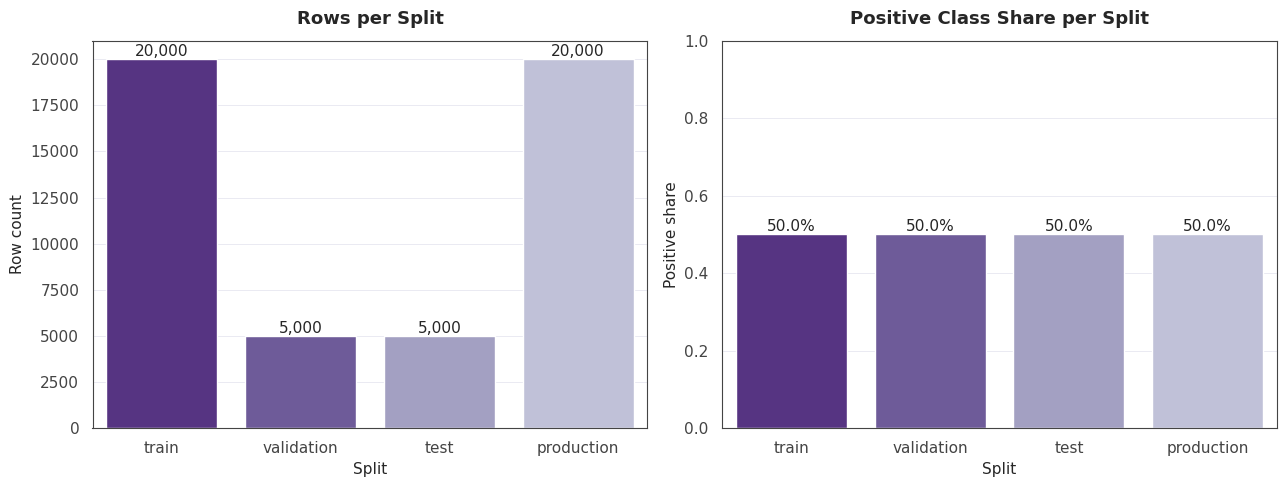

In [5]:
split_order = ["train", "validation", "test", "production"]
plot_df = split_summary.reindex(split_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=plot_df,
    x="split_type",
    y="row_count",
    hue="split_type",
    palette=PURPLE_SPLITS,
    order=split_order,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Rows per Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Row count")
for i, row in plot_df.iterrows():
    axes[0].text(i, row["row_count"], f"{int(row['row_count']):,}", ha="center", va="bottom")

sns.barplot(
    data=plot_df,
    x="split_type",
    y="positive_share",
    hue="split_type",
    palette=PURPLE_SPLITS,
    order=split_order,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Positive Class Share per Split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Positive share")
axes[1].set_ylim(0, 1)
for i, row in plot_df.iterrows():
    axes[1].text(i, row["positive_share"], f"{row['positive_share']:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(report_dir / "feature_split_distribution.png", dpi=150)
plt.show()

## 4. Add Feature Store required columns

Every Feature Group needs a record identifier and an event time. We use `review_id` as the identifier and the current UTC timestamp as the event time.

In [6]:
features_df["event_time"] = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

FEATURE_COLUMNS = [
    "review_id", "business_id", "user_id", "stars", "sentiment", "sentiment_label",
    "review_text", "clean_text", "review_char_length", "review_word_count",
    "has_exclamation", "has_question", "review_year", "split_type", "event_time",
]
features_df = features_df[FEATURE_COLUMNS]
features_df.dtypes

review_id              object
business_id            object
user_id                object
stars                 float64
sentiment              object
sentiment_label         int64
review_text            object
clean_text             object
review_char_length      int64
review_word_count       int64
has_exclamation         int64
has_question            int64
review_year             int64
split_type             object
event_time             object
dtype: object

## 5. Create the SageMaker Feature Group

In [7]:
timestamp = strftime("%d-%H-%M-%S", gmtime())
feature_group_name = f"yelp-sentiment-feature-group-{timestamp}"

feature_definitions = [
    FeatureDefinition("review_id", FeatureTypeEnum.STRING),
    FeatureDefinition("business_id", FeatureTypeEnum.STRING),
    FeatureDefinition("user_id", FeatureTypeEnum.STRING),
    FeatureDefinition("stars", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("sentiment", FeatureTypeEnum.STRING),
    FeatureDefinition("sentiment_label", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("review_text", FeatureTypeEnum.STRING),
    FeatureDefinition("clean_text", FeatureTypeEnum.STRING),
    FeatureDefinition("review_char_length", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("review_word_count", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("has_exclamation", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("has_question", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("review_year", FeatureTypeEnum.INTEGRAL),
    FeatureDefinition("split_type", FeatureTypeEnum.STRING),
    FeatureDefinition("event_time", FeatureTypeEnum.STRING),
]

feature_group = FeatureGroup(
    name=feature_group_name,
    sagemaker_session=sagemaker_session,
    feature_definitions=feature_definitions,
)

feature_group.create(
    record_identifier_name="review_id",
    event_time_feature_name="event_time",
    role_arn=role,
    s3_uri=f"s3://{bucket}/feature-store/yelp-sentiment/{feature_group_name}",
    enable_online_store=False,
)

while feature_group.describe()["FeatureGroupStatus"] == "Creating":
    print("Waiting for feature group creation...")
    time.sleep(5)

print("Feature group ready:", feature_group_name)
%store feature_group_name

Waiting for feature group creation...


Waiting for feature group creation...


Waiting for feature group creation...


Waiting for feature group creation...


Waiting for feature group creation...


Waiting for feature group creation...


Waiting for feature group creation...


Waiting for feature group creation...


Feature group ready: yelp-sentiment-feature-group-26-01-05-20
Stored 'feature_group_name' (str)


## 6. Ingest the features

The Feature Store needs all column dtypes to match the feature definitions exactly. We cast a few columns explicitly to make this deterministic.

In [8]:
ingest_df = features_df.copy()
for col in ["stars", "sentiment_label", "review_char_length", "review_word_count", "has_exclamation", "has_question", "review_year"]:
    ingest_df[col] = ingest_df[col].astype("int64")
for col in ["review_id", "business_id", "user_id", "sentiment", "review_text", "clean_text", "split_type", "event_time"]:
    ingest_df[col] = ingest_df[col].astype(str)

ingest_df = ingest_df.drop_duplicates(subset=["review_id"]).reset_index(drop=True)
print(f"Ingesting {len(ingest_df):,} records...")

ingestion_manager = feature_group.ingest(data_frame=ingest_df, max_workers=4, wait=True)
print("Ingestion finished. Failed indices:", getattr(ingestion_manager, "_failed_indices", "unknown"))

Ingesting 50,000 records...


Ingestion finished. Failed indices: []


## 7. Describe and verify

In [9]:
description = feature_group.describe()
{k: description[k] for k in ["FeatureGroupName", "RecordIdentifierFeatureName", "EventTimeFeatureName", "FeatureGroupStatus", "OfflineStoreConfig"]}

{'FeatureGroupName': 'yelp-sentiment-feature-group-26-01-05-20',
 'RecordIdentifierFeatureName': 'review_id',
 'EventTimeFeatureName': 'event_time',
 'FeatureGroupStatus': 'Created',
 'OfflineStoreConfig': {'S3StorageConfig': {'S3Uri': 's3://yelp-sentiment-mlops-045456814877/feature-store/yelp-sentiment/yelp-sentiment-feature-group-26-01-05-20',
   'ResolvedOutputS3Uri': 's3://yelp-sentiment-mlops-045456814877/feature-store/yelp-sentiment/yelp-sentiment-feature-group-26-01-05-20/045456814877/sagemaker/us-east-1/offline-store/yelp-sentiment-feature-group-26-01-05-20-1779757520/data'},
  'DisableGlueTableCreation': False,
  'DataCatalogConfig': {'TableName': 'yelp_sentiment_feature_group_26_01_05_20_1779757520',
   'Catalog': 'AwsDataCatalog',
   'Database': 'sagemaker_featurestore'}}}

In [10]:
offline_table = description["OfflineStoreConfig"]["DataCatalogConfig"]["TableName"]
offline_db = description["OfflineStoreConfig"]["DataCatalogConfig"]["Database"]
print(f"Offline store table: {offline_db}.{offline_table}")
print("Note: it can take a few minutes for offline data to land in S3 before this Athena query returns rows.")
%store offline_table
%store offline_db

Offline store table: sagemaker_featurestore.yelp_sentiment_feature_group_26_01_05_20_1779757520
Note: it can take a few minutes for offline data to land in S3 before this Athena query returns rows.
Stored 'offline_table' (str)
Stored 'offline_db' (str)


In [11]:
split_dist = features_df["split_type"].value_counts().rename_axis("split_type").reset_index(name="row_count")
split_dist["share"] = (split_dist["row_count"] / split_dist["row_count"].sum()).round(4)
split_dist

,split_type,row_count,share
0,train,20000,0.4
1,production,20000,0.4
2,validation,5000,0.1
3,test,5000,0.1


## Persist split CSVs to S3 for downstream notebooks

Materializing each split to its own S3 prefix means later notebooks (training, monitoring, batch inference) can read each split with a single `pd.read_csv` without needing to query the Feature Store every time.

In [12]:
import awswrangler as wr

split_prefix = "processed/splits"
for split_name in ["train", "validation", "test", "production"]:
    subset = features_df[features_df["split_type"] == split_name]
    target = f"s3://{bucket}/{split_prefix}/{split_name}/{split_name}.csv"
    wr.s3.to_csv(df=subset, path=target, index=False)
    print(f"Wrote {len(subset):,} rows to {target}")
%store split_prefix

2026-05-26 01:08:23,420	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 1909420032 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.48gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-26 01:08:23,579	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Wrote 20,000 rows to s3://yelp-sentiment-mlops-045456814877/processed/splits/train/train.csv


Wrote 5,000 rows to s3://yelp-sentiment-mlops-045456814877/processed/splits/validation/validation.csv


Wrote 5,000 rows to s3://yelp-sentiment-mlops-045456814877/processed/splits/test/test.csv


Wrote 20,000 rows to s3://yelp-sentiment-mlops-045456814877/processed/splits/production/production.csv
Stored 'split_prefix' (str)


## Done

Continue to `04_dataset_splits.ipynb` to verify the splits and produce the final summary table for the design document.